In [1]:
# Import the needed libraries
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

# Import the dataset
data = pd.read_csv(r"C:\Users\ugoch\OneDrive\Desktop\PROJECTS\EXPLORATORY_DATA_ANALYSIS_PROJECTS\BIKE_SALES_DATASET\bike_sales_messy_dataset.csv")


In [2]:
# What is the Data size?
print(f'Number of Rows/Records: {data.shape[0]}\nNumber of Columns/Variables: {data.shape[1]}')

Number of Rows/Records: 735000
Number of Columns/Variables: 24


In [3]:
# What other information can be derived?
print("Dataset Information \n")
print(data.info(), "\n")


# How many missing values in each column?
print("\nHow many Missing Values in each column? \n")
print(data.isnull().sum().sort_values(ascending = False), "\n")


# What is the percentage of missing values in each column?
print("\nPercentage of Missing Values in each column. \n")
print((data.isnull().mean() * 100).round(2).sort_values(ascending = False))

Dataset Information 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735000 entries, 0 to 734999
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            735000 non-null  int64  
 1   Date of Purchase    727661 non-null  object 
 2   Quantity sold       733199 non-null  object 
 3   Total Revenue       735000 non-null  float64
 4   Cost                735000 non-null  float64
 5   Profit              735000 non-null  float64
 6   Discount Applied    668784 non-null  object 
 7   Customer Age        732825 non-null  object 
 8   Gender              701514 non-null  object 
 9   Marital Status      653316 non-null  object 
 10  Income              733791 non-null  object 
 11  Educational Level   701505 non-null  object 
 12  Occupation          704382 non-null  object 
 13  Product Category    720262 non-null  object 
 14  Type of Bike        367535 non-null  object 
 15  Model       

In [4]:
# Create a function that handles the analysis
def analyze_dataset(df):
        
    # Get the data types
    se_dtype = df.dtypes
    data_explore = pd.DataFrame(se_dtype, columns = ['Data Types'])
    
        
    # Get the Missing values count (mvc)
    se_mvc = df.isnull().sum()

    # Get the Missing values percentage (mvp)
    se_mvp = (df.isnull().mean() * 100).round(2)
    
    # Get the number of non-missing records
    se_number_records = df.count() 


    # Combining them into one table
    data_explore['Missing Cells'] = se_mvc
    data_explore['Missing Cells (%)'] = se_mvp
    data_explore['Non-Missing Cells'] = se_number_records
    result = data_explore.sort_values(by = 'Missing Cells (%)', ascending = False)
    
    return result

analyze_dataset(data)

,Data Types,Missing Cells,Missing Cells (%),Non-Missing Cells
Type of Bike,object,367465,50.00,367535
Commute Distance,object,113003,15.37,621997
Brand,object,106732,14.52,628268
Color,object,82609,11.24,652391
Marital Status,object,81684,11.11,653316
Size,object,71608,9.74,663392
Discount Applied,object,66216,9.01,668784
Home Ownership,object,61112,8.31,673888
Model,object,55929,7.61,679071
Gender,object,33486,4.56,701514


In [5]:
# Determine the number of duplicated records in the dataset
print("Number of duplicate records/rows/observations: ")
print(data.duplicated().sum())


print("\nThe Duplicate Rows are: ")
data[data.duplicated(keep = False)].sort_values(by = list(data.columns))

Number of duplicate records/rows/observations: 
35000

The Duplicate Rows are: 


,Order ID,Date of Purchase,Quantity sold,Total Revenue,Cost,Profit,Discount Applied,Customer Age,Gender,Marital Status,...,Type of Bike,Model,Color,Size,Brand,Commute Distance,Home Ownership,Number of Cars,Number of Children,Purchased or Not
31177,1,2020-10-19 16:46:05,1,3000.0,2059.55,940.45,0.3,66,Male,complicated,...,E-Bike,Speedster,blue,One Size,Trek,<1 mile,OWN,0,0,Yes
368823,1,2020-10-19 16:46:05,1,3000.0,2059.55,940.45,0.3,66,Male,complicated,...,E-Bike,Speedster,blue,One Size,Trek,<1 mile,OWN,0,0,Yes
328617,19,2025-11-24 02:06:26,1,1000.0,534.56,465.44,0,63,Mâle,S,...,e-bike,X1,Green,s,trek,unknown,NaN,0,3,Yes
329784,19,2025-11-24 02:06:26,1,1000.0,534.56,465.44,0,63,Mâle,S,...,e-bike,X1,Green,s,trek,unknown,NaN,0,3,Yes
203816,48,2021-08-21 16:30:09,4,280.0,142.58,137.42,0.15,50,man,D,...,NaN,NaN,White,One Size,Shimano,car,Mortgage,2,2,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475896,699966,2024-08-05 16:25:31,1,3000.0,2246.49,753.51,none,63,unknown,married,...,Mountain,CityRide,White,m,Giant,train,mortgage,0,0,Yes
388655,699973,2022-09-13 23:04:38,2,1000.0,649.30,350.70,20 percent,31,FEMALE,Married,...,Mountain,elite,Yellow,One Size,Giant,train,unknown,3,2,did not buy
637414,699973,2022-09-13 23:04:38,2,1000.0,649.30,350.70,20 percent,31,FEMALE,Married,...,Mountain,elite,Yellow,One Size,Giant,train,unknown,3,2,did not buy
588659,699998,2025-05-17 15:51:47,1,80.0,43.22,36.78,0.2,50,f,Widowed,...,NaN,Pump,Black,M,Pearl Izumi,car,RENT,1,0,No


In [6]:
# Derive some descriptive statistics 

data.describe(include = 'all')

,Order ID,Date of Purchase,Quantity sold,Total Revenue,Cost,Profit,Discount Applied,Customer Age,Gender,Marital Status,...,Type of Bike,Model,Color,Size,Brand,Commute Distance,Home Ownership,Number of Cars,Number of Children,Purchased or Not
count,735000.000000,727661,733199,735000.000000,735000.000000,735000.000000,668784,732825,701514,653316,...,367535,679071,652391,663392,628268,621997,673888,732882,732882,727647
unique,NaN,691575,16,NaN,NaN,NaN,12,79,21,16,...,9,26,12,14,12,11,11,12,13,28
top,NaN,invalid date,1,NaN,NaN,NaN,0,30,f,married,...,Electric,X2,Black,S,Bell,train,RENT,1,0,Yes
freq,NaN,107,477354,NaN,NaN,NaN,293862,10454,33834,41104,...,41252,40972,82729,71705,61503,56869,61525,241144,323441,256799
mean,349963.207019,NaN,NaN,1236.091087,803.867159,432.223929,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,202043.415756,NaN,NaN,1814.210441,1195.039119,662.379271,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,174934.750000,NaN,NaN,60.000000,37.650000,19.770000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,350007.500000,NaN,NaN,450.000000,255.505000,116.720000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,524966.250000,NaN,NaN,2000.000000,1210.290000,638.860000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Extracting Customer Data

In [7]:
# Customer Data columns
customer_data_columns = ['Order ID', 'Date of Purchase', 'Customer Age', 'Gender',
       'Marital Status', 'Income', 'Educational Level', 'Occupation', 'Commute Distance', 
        'Home Ownership', 'Number of Cars','Number of Children', 'Purchased or Not']

# Retrieve Customer Dataset
customer_data = data[customer_data_columns].copy()
customer_data

,Order ID,Date of Purchase,Customer Age,Gender,Marital Status,Income,Educational Level,Occupation,Commute Distance,Home Ownership,Number of Cars,Number of Children,Purchased or Not
0,562534,2021-10-11 16:12:27,30,Non-binary,Married,64720.27171227959,bs,Manager,NaN,unknown,1,2,✔️
1,94346,2024-03-13 18:44:54,42,man,Single,54224.76354784306,ged,unemp,3-5 miles,Own,2,0,✔️
2,37446,2021-04-05 16:36:01,60,FEMALE,Widowed,80926.50371626599,dropout,NaN,walk,Mortgage,3,1,N
3,354279,2025-01-24 23:40:31,50,feMale,D,8929.258846415716,masters,nurse,unknown,other,1,1,Yes
4,515537,2021-02-15 14:55:15,42,unknown,S,62573.43144788382,Bachelor's,Engineer,unknown,NaN,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
734995,382795,2022-06-01 08:22:46,63,♀,Divorced,66775.1689326152,unknown,Sales,NaN,other,1,0,No
734996,261778,2025-06-24 06:27:56,45,Fémale,Separated,21651.340179919447,elementary,engr,NaN,Rent,1,1,No
734997,306747,2021-07-24 07:18:36,27,m,NaN,60020.492058554926,dropout,teach,train,Rent,1,0,No
734998,424175,2020-02-03 18:32:05,old,man,Widowed,73146.12027640859,bachelors,Doctor,unknown,own,3,0,0


In [8]:
# Show Statistics
customer_data.describe(include = 'all')

,Order ID,Date of Purchase,Customer Age,Gender,Marital Status,Income,Educational Level,Occupation,Commute Distance,Home Ownership,Number of Cars,Number of Children,Purchased or Not
count,735000.000000,727661,732825,701514,653316,733791,701505,704382,621997,673888,732882,732882,727647
unique,NaN,691575,79,21,16,676431,21,23,11,11,12,13,28
top,NaN,invalid date,30,f,married,0.0,unknown,teach,train,RENT,1,0,Yes
freq,NaN,107,10454,33834,41104,10099,33741,30995,56869,61525,241144,323441,256799
mean,349963.207019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,202043.415756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,174934.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,350007.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,524966.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Order Number

In [9]:
# Total number of data points is 735000
# Has Minimum value of 1 and Maximum value of 700000
# Thus has 35000 duplicate values.
# Integer data type as expected.
# No Cleaning needed

## Date of Purchase

In [10]:
print("Count of data in dataset: ", customer_data['Date of Purchase'].count())
print("Count of missing values: ", customer_data['Date of Purchase'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Date of Purchase'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")



# Total number of data points less than 735000
# Thus has missing values.
# Has an entry "invalid date".
# Represented as an Object data type instead of date.
# Needs Cleaning.



# Check for any NON-NUMERICAL DATA POINTS.
# Or DATA POINTS that may contain TEXT characters.
mask = (customer_data['Date of Purchase']
        .astype(str)
        .str.contains(r'[a-zA-Z]')
       )
customer_data.loc[mask, 'Date of Purchase'].unique()


# OBSERVATIONS.
#1. Contains the value 'yesterday' in addition to 'invalid date'.
#2. The entry nan confirms the existence of missing values.

Count of data in dataset:  727661
Count of missing values:  7339
Percent missing values: (%) 1.0 



array([nan, 'invalid date', 'yesterday'], dtype=object)

# NUMERICAL COLUMNS

## Income

Count of data in dataset:  733791
Count of missing values:  1209
Percent missing values: (%) 0.16 

['100k+' '>200k' '45k' '$45,000' '-1' nan 'rich' '-10000' 'zero' 'unknown'
 'fifty thousand'] 

count    7.239500e+05
mean     7.102666e+04
std      4.011051e+05
min     -1.000000e+04
25%      3.796521e+04
50%      5.494206e+04
75%      7.182309e+04
max      9.999999e+06
Name: Income, dtype: float64


Text(0.5, 0.98, 'Distribution of Income Dataset)')

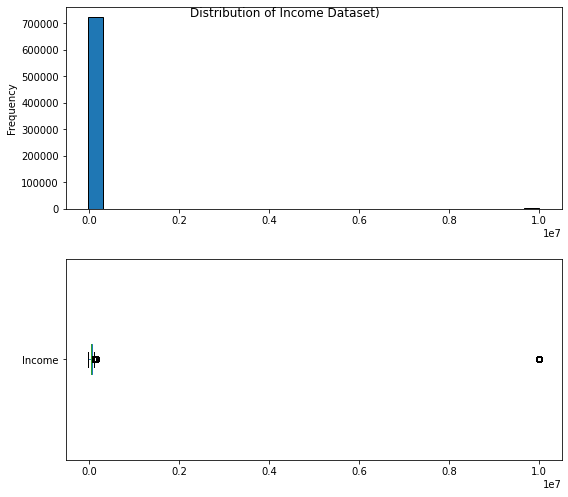

In [11]:
print("Count of data in dataset: ", customer_data['Income'].count())
print("Count of missing values: ", customer_data['Income'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Income'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Represented as Object data type.
# Has data points less than 735000.
# Descriptive Statistics (max, min, percentiles, etc.) show as NaN; indicating data value errors.



# Check for any NON-NUMERICAL DATA POINTS.
# Or DATA POINTS that may contain TEXT characters.
mask = (customer_data['Income']
       .astype(str)
       .str.contains(r'[^0-9.]')
       )
print(customer_data.loc[mask, 'Income'].unique(), "\n")



# Convert the NUMERICAL representations of data points to ACTUAL NUMBERS.
numerical_income = pd.to_numeric(customer_data['Income'], errors = 'coerce')


# Descriptive Statistics of the NUMERICAL DATA POINTS.
print(numerical_income.describe())


# DISTRIBUTION OF NUMERICAL DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
numerical_income.plot(kind = 'hist', bins = 30, edgecolor = 'black', ax = ax[0])
numerical_income.plot(kind = 'box', vert = False, ax = ax[1])
plt.tight_layout(h_pad = 2)
plt.suptitle('Distribution of Income Dataset')



# OBSERVATIONS.
#1. Non-numerical data points contained in the dataset include '100k+', '>200k', '45k','$45,000', 'rich', 'zero', 
### 'unknown', 'fifty thousand' .
#2. The entry nan confirms the existence of missing values.
#3. Contains negative values (-1, -10000).
#4. Has outlier value (of 9999999).

## Customer Age

Count of data in dataset:  732825
Count of missing values:  2175
Percent missing values: (%) 0.3 

['thirty' nan 'old' 'forty-five' '-5' 'unknown' '18 years' '25+'] 

count    719459.000000
mean         52.425220
std          56.096099
min          -5.000000
25%          32.000000
50%          50.000000
75%          67.000000
max         999.000000
Name: Customer Age, dtype: float64


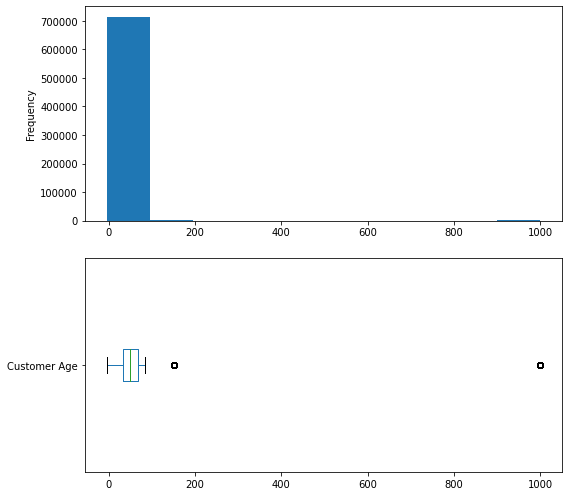

In [12]:
print("Count of data in dataset: ", customer_data['Customer Age'].count())
print("Count of missing values: ", customer_data['Customer Age'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Customer Age'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Represented as Object data type.
# Has data points less than 735000.
# Descriptive Statistics (max, min, percentiles) are NOT AVAILABLE; indicating data value errors.


# Check for any NON-NUMERICAL DATA POINTS.
# Or DATA POINTS that may contain TEXT characters.
mask = (customer_data['Customer Age']
       .astype(str)
       .str.contains(r'[^0-9]')
       )
print(customer_data.loc[mask, 'Customer Age'].unique(), "\n")


# Convert the NUMERICAL representations of data points to ACTUAL NUMBERS.
numerical_age = pd.to_numeric(customer_data['Customer Age'], errors = 'coerce')


# Descriptive Statistics of the NUMERICAL DATA POINTS.
print(numerical_age.describe())


# DISTRIBUTION OF NUMERICAL DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
numerical_age.plot(kind = 'hist', ax = ax[0])
numerical_age.plot(kind = 'box', vert = False, ax = ax[1])
plt.tight_layout(h_pad = 2)



# OBSERVATIONS.
#1. Contains non-numerical values like 'thirty', 'old','forty-five', 'unknown', '18 years', '25+' .
#2. The entry nan confirms the existence of missing values.
#3. Contains negative values (-5).
#4. Has outlier value (e.g 999 etc.).

## Number of Cars

Count of data in dataset:  732882
Count of missing values:  2118
Percent missing values: (%) 0.29 

[nan 'none' 'many' '-1' 'unknown' 'several'] 

count    724446.000000
mean          1.763255
std           5.325324
min          -1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          99.000000
Name: Number of Cars, dtype: float64


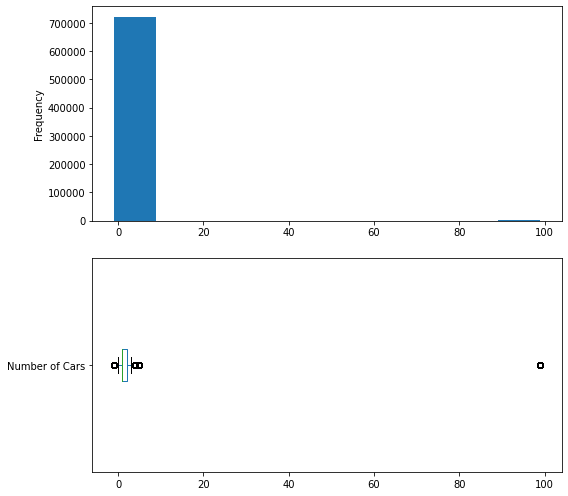

In [13]:
print("Count of data in dataset: ", customer_data['Number of Cars'].count())
print("Count of missing values: ", customer_data['Number of Cars'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Number of Cars'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Represented as Object (or String) data type.
# Has data points less than 735000.
# Descriptive Statistics (max, min, percentiles) are NOT AVAILABLE; indicating data value errors.


# Check for any NON-NUMERICAL DATA POINTS.
# Or DATA POINTS that may contain TEXT characters.
mask = (customer_data['Number of Cars']
       .astype(str)
       .str.contains(r'[^0-9]')
       )
print(customer_data.loc[mask, 'Number of Cars'].unique(), "\n")


# Convert the NUMERICAL representations of data points to ACTUAL NUMBERS.
numerical_cars = pd.to_numeric(customer_data['Number of Cars'], errors = 'coerce')


# Descriptive Statistics of the NUMERICAL DATA POINTS.
print(numerical_cars.describe())


# DISTRIBUTION OF NUMERICAL DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
numerical_cars.plot(kind = 'hist', ax = ax[0])
numerical_cars.plot(kind = 'box', vert = False, ax = ax[1])
plt.tight_layout(h_pad = 2)



# OBSERVATIONS.
#1. Contains non-numerical values like 'none', 'many', 'unknown', and 'several'.
#2. The entry nan confirms the existence of missing values.
#3. Contains negative values (-1).
#4. Has outlier (value of 99).

## Number of Children

Count of data in dataset:  732882
Count of missing values:  2118
Percent missing values: (%) 0.29 

['many' 'twins' '-5' nan 'unknown' 'none'] 

count    724413.000000
mean          0.927061
std           2.808722
min          -5.000000
25%           0.000000
50%           1.000000
75%           1.000000
max          50.000000
Name: Number of Children, dtype: float64


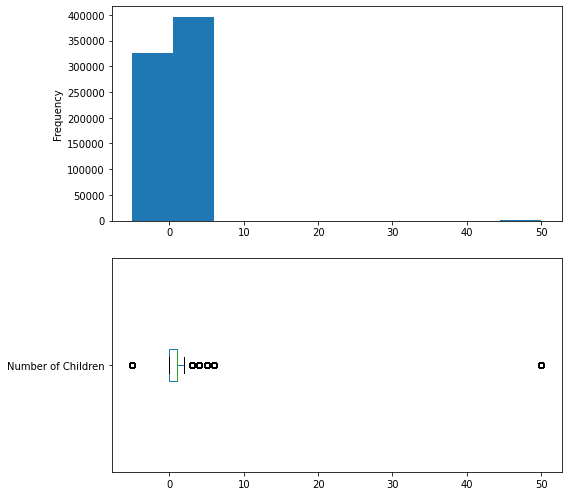

In [14]:
print("Count of data in dataset: ", customer_data['Number of Children'].count())
print("Count of missing values: ", customer_data['Number of Children'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Number of Children'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Represented as Object (or String) data type.
# Has data points less than 735000.
# Descriptive Statistics (max, min, percentiles) are NOT AVAILABLE; indicating data value errors.


# Check for any NON-NUMERICAL DATA POINTS.
# Or DATA POINTS that may contain TEXT characters.
mask = (customer_data['Number of Children']
       .astype(str)
       .str.contains(r'[^0-9]')
       )
print(customer_data.loc[mask, 'Number of Children'].unique(), "\n")


# Convert the NUMERICAL representations of data points to ACTUAL NUMBERS.
numerical_children = pd.to_numeric(customer_data['Number of Children'], errors = 'coerce')


# Descriptive Statistics of the NUMERICAL DATA POINTS.
print(numerical_children.describe())


# DISTRIBUTION OF NUMERICAL DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
numerical_children.plot(kind = 'hist', ax = ax[0])
numerical_children.plot(kind = 'box', vert = False, ax = ax[1])
plt.tight_layout(h_pad = 2)



# OBSERVATIONS.
#1. Contains non-numerical values like 'many', 'twins', 'unknown', and 'none'.
#2. The entry nan confirms the existence of missing values.
#3. Contains negative values (-5).
#4. Has outlier (value of 50).

# Categorical Columns

In [15]:
customer_data.select_dtypes(include = 'object').columns

Index(['Date of Purchase', 'Customer Age', 'Gender', 'Marital Status',
       'Income', 'Educational Level', 'Occupation', 'Commute Distance',
       'Home Ownership', 'Number of Cars', 'Number of Children',
       'Purchased or Not'],
      dtype='object')

## Gender

Count of data in dataset:  701514
Count of missing values:  33486
Percent missing values: (%) 4.56 

Number of Unique Entries: 21 

Unique Values are: 

['Non-binary' 'man' 'FEMALE' 'feMale' 'unknown' '♀' 'Female' 'f' 'F' '♂'
 'mail' 'she/her' 'M' 'prefer not to say' 'woman' 'm' 'he/him' nan 'Mâle'
 'MALE' 'Male' 'Fémale'] 

f                    33834
FEMALE               33757
woman                33756
m                    33687
Fémale               33615
Non-binary           33552
feMale               33481
unknown              33470
♀                    33466
M                    33421
Male                 33372
MALE                 33363
she/her              33284
Female               33266
he/him               33258
man                  33232
prefer not to say    33221
♂                    33213
F                    33104
mail                 33083
Mâle                 33079
Name: Gender, dtype: int64 



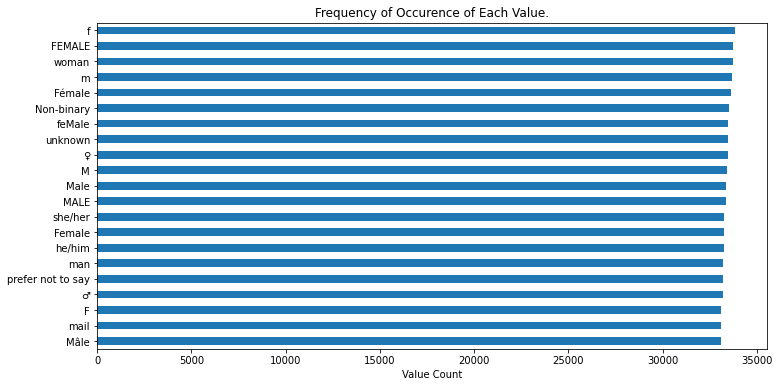

In [16]:
print("Count of data in dataset: ", customer_data['Gender'].count())
print("Count of missing values: ", customer_data['Gender'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Gender'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Confirm number of unique entries
print("Number of Unique Entries:",customer_data['Gender'].nunique(), "\n")


# Contains missing values as data points less than 735000.
# Contains twenty-one (21) unique values which is higher than the number of common gender identities (7). An indication
# of possible errors (formatting errors or inconsistency) in values.
# N/B: Common Gender Identities:
    ## Man (Male)/Woman(Female) , Cisgender, Transgender, Non-binary, Agender, Genderfluid, and Bigender.


# Derive the unique entries 
print("Unique Values are: \n")
print(customer_data['Gender'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['Gender'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['Gender'].value_counts(ascending = True).plot(kind = 'barh')
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Each Value.')
plt.show()


# OBSERVATIONS:
#1. Inconsistent values / Different representations of the same gender category (e.g. man, male, Male, Mail, ♂).
#2. All representations have the same order of magnitude of frequency occurrence(33,000+ data points).
#3. Presence of nan confirms missing values.
#4. Invalid value 'prefer not to say' that does not refer to any gender.
#5. Inconsistent formatting of values (e.g (FEMALE, Female, female, feMale), (male, Mâle, Male, MALE))

## Marital Status

Count of data in dataset:  653316
Count of missing values:  81684
Percent missing values: (%) 11.11 

Number of Unique Entries: 16 

Unique Values are:

['Married ' 'Single' 'Widowed' 'D' 'S' nan 'living together' 'complicated'
 'W' 'Separated' 'M' 'married' 'single' 'Married' ' Single' 'Divorced'
 'unknown'] 

married            41104
Divorced           41054
unknown            41037
M                  41027
Separated          40942
D                  40942
Widowed            40864
single             40832
 Single            40792
W                  40775
living together    40736
Single             40728
Married            40724
S                  40674
Married            40655
complicated        40430
Name: Marital Status, dtype: int64 



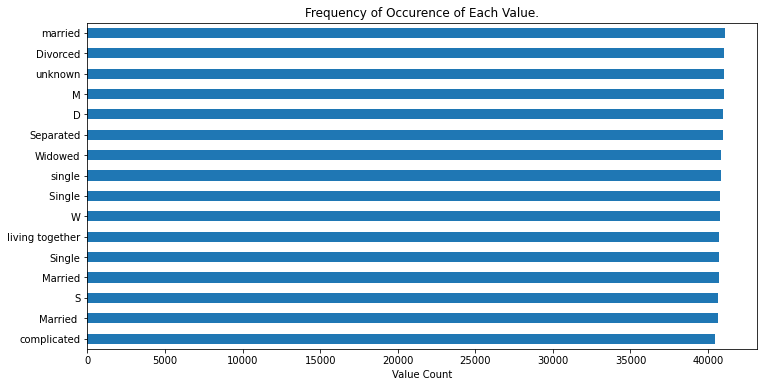

In [17]:
print("Count of data in dataset: ", customer_data['Marital Status'].count())
print("Count of missing values: ", customer_data['Marital Status'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Marital Status'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Confirm number of unique entries
print("Number of Unique Entries:",customer_data['Marital Status'].nunique(), "\n")


# Contains missing values as data points less than 735000.
# Contains sixteen (16) unique values which is higher than the number of common marital status categories (6). An indication
# of possible errors (formatting errors or inconsistency) in values.
# N/B: Common Marital Status Categories are;
    ## Single, Married, Common-law, Separated, Divorced, and Widowed.


# Derive the unique entries 
print("Unique Values are:\n")
print(customer_data['Marital Status'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['Marital Status'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['Marital Status'].value_counts(ascending = True).plot(kind = 'barh')
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Each Value.')
plt.show()


# OBSERVATIONS
#1. Some entries have leading and/or trailing spaces.
#2. All entries have the same order of magnitude of frequency occurrence(40,000+ data points).
#3. Presence of nan confirms missing values.
#4. Inconsistent formatting of values (e.g. ('Married', 'Married ' and 'married'), ('Single',' Single' and 'single')).
#5. Inconsistent entry for certain datasets (e.g (M, married, Married), (S, single, Single), etc)

## Educational Level

Count of data in dataset:  701505
Count of missing values:  33495
Percent missing values: (%) 4.56 

Number of Unique Entries: 21 

Unique Values are:

['bs' 'ged' 'dropout' 'masters' "Bachelor's" 'doctorate' 'ba' 'bachelors'
 "Master's" 'ma' 'elementary' 'High School' 'unknown' 'ms' 'PhD'
 'highschool' 'hs' 'Some College' 'Associate' 'none' 'phd' nan] 

unknown         33741
none            33709
highschool      33699
phd             33669
hs              33605
doctorate       33575
bachelors       33532
ma              33493
ms              33475
Associate       33460
Some College    33427
dropout         33399
PhD             33393
ba              33382
elementary      33361
bs              33176
High School     33169
Master's        33162
Bachelor's      33080
ged             33010
masters         32988
Name: Educational Level, dtype: int64 



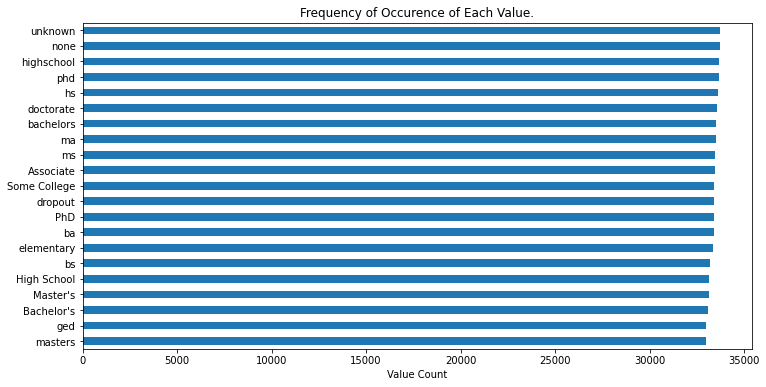

In [18]:
print("Count of data in dataset: ", customer_data['Educational Level'].count())
print("Count of missing values: ", customer_data['Educational Level'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Educational Level'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Confirm number of unique entries
print("Number of Unique Entries:",customer_data['Educational Level'].nunique(), "\n")


# Contains missing values as data points less than 735000.
# Contains twenty-one (21) unique values which is higher than the number of common educational levels (9). An indication
# of possible errors (formatting errors or inconsistency) in values.
# N/B: Recognized Educational Levels are:
    ## Early Childhood Education, Primary Education, Lower Secondary Education, Upper Secondary Education,
    ## Post Secondary Non-Tertiary, Short Cycle Tertiary (College), Bachelors, Masters, and Doctoral.

    
# Derive the unique entries 
print("Unique Values are:\n")
print(customer_data['Educational Level'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['Educational Level'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['Educational Level'].value_counts(ascending = True).plot(kind = 'barh')
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Each Value.')
plt.show()


# OBSERVATIONS
#1. All entries have the same order of magnitude of frequency occurrence(33,000+ data points).
#2. Presence of nan confirms missing values.
#3. Inconsistent formatting of values (e.g (phd, PhD), (bachelors,Bachelor's), etc).
#4. Inconsistent entry for certain datasets (e.g (phd, PhD, doctorate), (bachelors, ba, Bachelor's), etc)
#4. Contains a value 'none' which indicates 'No Educational Level'.

## Occupation

Count of data in dataset:  704382
Count of missing values:  30618
Percent missing values: (%) 4.17 

Number of Unique Entries: 23 

Unique Values are:

['Manager' 'unemp' nan 'nurse' 'Engineer' 'artist' 'ret' 'Other' 'Student'
 'Retired' 'freelancer' 'Doctor' 'Teacher' 'Sales' 'stud' 'unknown'
 'Unemployed' 'writer' 'doc' 'coder' 'lawyer' 'homemaker' 'engr' 'teach'] 

teach         30995
nurse         30854
artist        30814
Retired       30805
Teacher       30753
Sales         30748
stud          30681
Doctor        30672
coder         30653
Manager       30635
Other         30631
unknown       30620
freelancer    30613
doc           30565
unemp         30563
writer        30559
Unemployed    30545
homemaker     30534
Student       30529
lawyer        30492
Engineer      30430
engr          30369
ret           30322
Name: Occupation, dtype: int64 



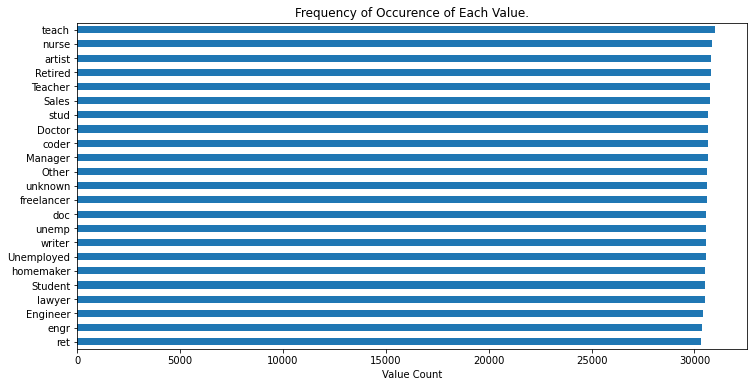

In [19]:
print("Count of data in dataset: ", customer_data['Occupation'].count())
print("Count of missing values: ", customer_data['Occupation'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Occupation'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Confirm number of unique entries
print("Number of Unique Entries:",customer_data['Occupation'].nunique(), "\n")


# Contains missing values as data points less than 735000.
# Contains twenty-three (23) unique values which is less than the number of occupations known worldwide. Close examination
# of unique values will expose any errors.


# Derive the unique entries 
print("Unique Values are:\n")
print(customer_data['Occupation'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['Occupation'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['Occupation'].value_counts(ascending = True).plot(kind = 'barh')
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Each Value.')
plt.show()


# OBSERVATIONS
#1. All entries have the same order of magnitude of frequency occurrence(30,000+ data points).
#2. Presence of nan confirms missing values.
#3. Inconsistent foramtting of values (e.g (stud, Student), (teach, Teacher), (umemp, Unemployed), (engr, Engineer) etc).

## Home Ownership

Count of data in dataset:  673888
Count of missing values:  61112
Percent missing values: (%) 8.31 

Number of Unique Entries: 11 

Unique Values are:

['unknown' 'Own' 'Mortgage' 'other' nan 'Rent' 'own' 'mortgage' 'OWN'
 'RENT' 'rent' 'living with parents'] 

RENT                   61525
Mortgage               61488
own                    61454
OWN                    61398
other                  61262
mortgage               61234
rent                   61183
living with parents    61162
Rent                   61133
Own                    61032
unknown                61017
Name: Home Ownership, dtype: int64 



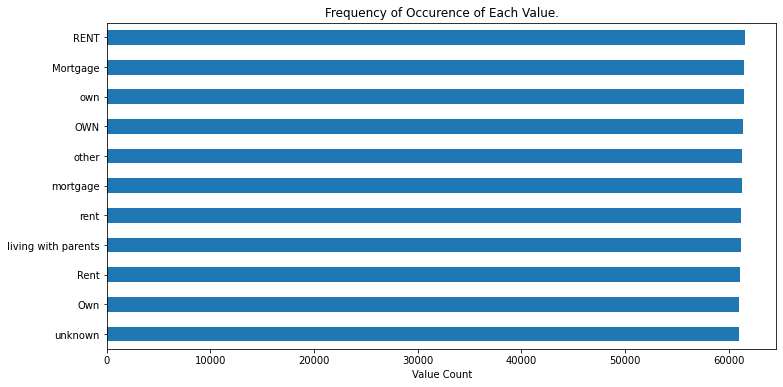

In [20]:
print("Count of data in dataset: ", customer_data['Home Ownership'].count())
print("Count of missing values: ", customer_data['Home Ownership'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Home Ownership'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Confirm number of unique entries
print("Number of Unique Entries:",customer_data['Home Ownership'].nunique(), "\n")


# Contains missing values as data points less than 735000.
# Contains eleven (11) unique values (due to format errors and inconsistent values).


# Derive the unique entries 
print("Unique Values are:\n")
print(customer_data['Home Ownership'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['Home Ownership'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['Home Ownership'].value_counts(ascending = True).plot(kind = 'barh')
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Each Value.')
plt.show()


# OBSERVATIONS
#1. All entries have the same order of magnitude of frequency occurrence(61,000+ data points).
#2. Presence of nan confirms missing values.
#3. Inconsistent formatting of values (e.g. (rent, RENT, Rent), (own, OWN, Own), (mortgage, Mortgage), etc).

## Commute Distance

Count of data in dataset:  621997
Count of missing values:  113003
Percent missing values: (%) 15.37 

Number of Unique Entries: 11 

Unique Values are:

[nan '3-5 miles' 'walk' 'unknown' '1-2 miles' '<1 mile' 'bike' 'car'
 'train' '0' '5-10 miles' '10+ miles'] 

train         56869
<1 mile       56816
car           56740
walk          56698
unknown       56617
0             56565
1-2 miles     56517
3-5 miles     56424
bike          56411
10+ miles     56398
5-10 miles    55942
Name: Commute Distance, dtype: int64 



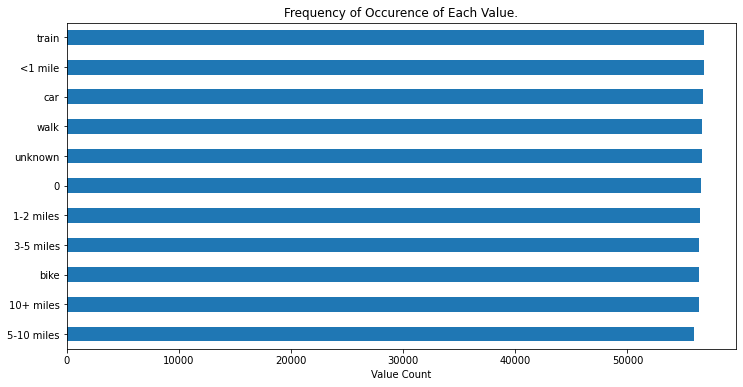

In [21]:
print("Count of data in dataset: ", customer_data['Commute Distance'].count())
print("Count of missing values: ", customer_data['Commute Distance'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Commute Distance'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Confirm number of unique entries
print("Number of Unique Entries:",customer_data['Commute Distance'].nunique(), "\n")


# Contains missing values as data points less than 735000.
# Contains eleven (11) unique values (due to format errors and inconsistent values).


# Derive the unique entries 
print("Unique Values are:\n")
print(customer_data['Commute Distance'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['Commute Distance'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['Commute Distance'].value_counts(ascending = True).plot(kind = 'barh')
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Each Value.')
plt.show()


# OBSERVATIONS
#1. All entries have the same order of magnitude of frequency occurrence(56,000+ data points).
#2.Un-necessary values (e.g. walk, car, train, and bike).
#3. Presence of nan confirms presence of missing values.

## Purcahsed or Not

Count of data in dataset:  727647
Count of missing values:  7353
Percent missing values: (%) 1.0 

Number of Unique Entries: 28 

Unique Values are:

['✔️' 'N' 'Yes' 'No' 'Y' 'bought' 'NO' 'yes' 'n' 'unknown' 'True' 'y' '❌'
 '1' 'purchased' 'not purchased' '0' nan 'False' 'TRUE' 'no' '✖️' '✅'
 'did not buy' 'FALSE' 'maybe' 'true' 'false' 'YES'] 

Yes              256799
No               235535
N                 22166
Y                 21961
yes               14805
no                14531
true               7533
❌                  7474
False              7467
bought             7457
0                  7448
false              7430
FALSE              7429
1                  7406
✔️                 7382
not purchased      7378
maybe              7359
unknown            7339
n                  7337
TRUE               7302
True               7293
purchased          7290
YES                7287
did not buy        7275
y                  7262
NO                 7249
✅                  7247
✖️ 

C:\Users\ugoch\anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ugoch\anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


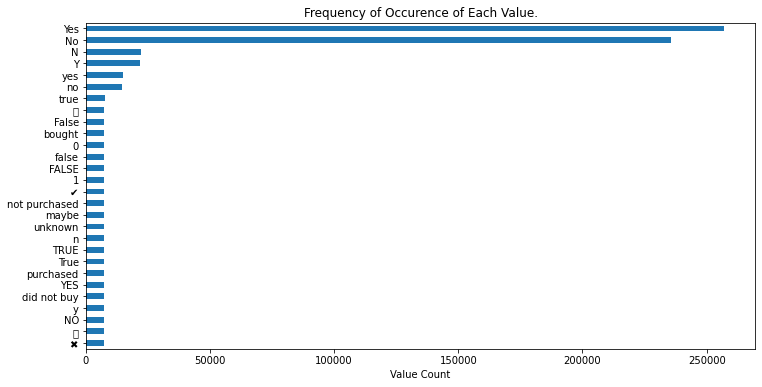

In [22]:
print("Count of data in dataset: ", customer_data['Purchased or Not'].count())
print("Count of missing values: ", customer_data['Purchased or Not'].isna().sum())
print("Percent missing values: (%)", ((customer_data['Purchased or Not'].isna().sum()/customer_data.shape[0])*100).round(2), "\n")


# Confirm number of unique entries
print("Number of Unique Entries:",customer_data['Purchased or Not'].nunique(), "\n")


# Contains missing values as data points less than 735000.
# Contains eleven (28) unique values (due to format errors, inconsistent values, and unwanted values). Way more than the
# two widely accepted answers of Yes or No.


# Derive the unique entries 
print("Unique Values are:\n")
print(customer_data['Purchased or Not'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['Purchased or Not'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['Purchased or Not'].value_counts(ascending = True).plot(kind = 'barh')
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Each Value.')
plt.show()


# OBSERVATIONS
#1. The entries Yes and No had the highest frequency occurrence(23,000+ data points). Other modifications had way less.
#2. Presence of nan confirms missing values.
#3. Inconsistent formatting of values (e.g. (Yes, YES, Y, yes, y etc).